In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------  9.7/9.8 MB 60.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 50.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 12.3/12.3 MB 77.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 84.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 63.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 67.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 62.6 MB/s eta 0:00:00
   ---------------------------------------- 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Desktop\AppData\Local\Temp\ipykernel_15756\378631347.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


¡Wireframe generado y guardado exitosamente en: ../docs/wireframe_dashboard.png!


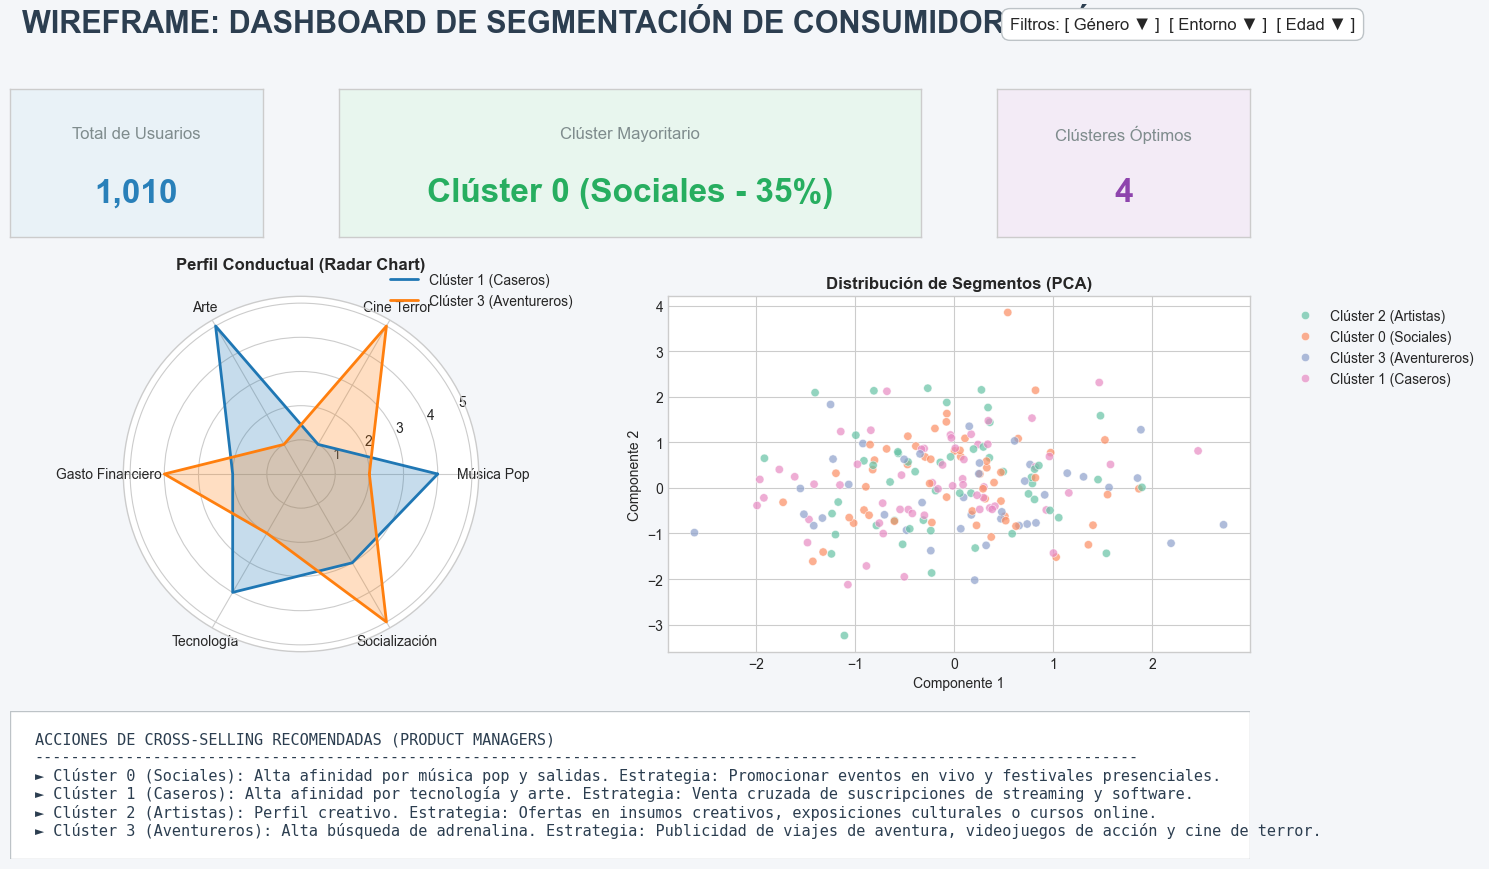


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import os

# Asegurar que la carpeta docs/ exista (subiendo un nivel desde notebooks/)
os.makedirs('../docs', exist_ok=True)

# 1. GENERACIÓN DE DATOS SIMULADOS (MOCK DATA CON PANDAS)
# Simulamos los resultados del PCA y K-Means para el Scatter Plot
np.random.seed(42)
df_mock = pd.DataFrame({
    'Componente 1': np.random.normal(0, 1, 200),
    'Componente 2': np.random.normal(0, 1, 200),
    'Cluster': np.random.choice(['Clúster 0 (Sociales)', 'Clúster 1 (Caseros)', 'Clúster 2 (Artistas)', 'Clúster 3 (Aventureros)'], 200)
})

# 2. CONFIGURACIÓN DEL LIENZO (DASHBOARD)
# Usamos un estilo limpio de wireframe
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 10), facecolor='#f4f6f9')
fig.suptitle('WIREFRAME: DASHBOARD DE SEGMENTACIÓN DE CONSUMIDORES JÓVENES', 
             fontsize=22, fontweight='bold', color='#2c3e50', y=0.96)

# Agregamos los filtros globales simulados en la parte superior derecha
fig.text(0.75, 0.94, 'Filtros: [ Género ▼ ]  [ Entorno ▼ ]  [ Edad ▼ ]', 
         fontsize=12, bbox=dict(facecolor='white', edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

# Definimos la cuadrícula (Grid) para acomodar los elementos: 4 filas x 4 columnas
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.3)

# 3. TARJETAS KPI (Top Level)
def crear_kpi(ax, titulo, valor, color):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.1, transform=ax.transAxes))
    ax.text(0.5, 0.7, titulo, ha='center', va='center', fontsize=12, color='#7f8c8d', transform=ax.transAxes)
    ax.text(0.5, 0.3, valor, ha='center', va='center', fontsize=24, fontweight='bold', color=color, transform=ax.transAxes)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

ax_kpi1 = fig.add_subplot(gs[0, 0])
crear_kpi(ax_kpi1, 'Total de Usuarios', '1,010', '#2980b9')

ax_kpi2 = fig.add_subplot(gs[0, 1:3])
crear_kpi(ax_kpi2, 'Clúster Mayoritario', 'Clúster 0 (Sociales - 35%)', '#27ae60')

ax_kpi3 = fig.add_subplot(gs[0, 3])
crear_kpi(ax_kpi3, 'Clústeres Óptimos', '4', '#8e44ad')

# 4. GRÁFICO PRINCIPAL: RADAR CHART (Centro Izquierda)
# Para simplificar en Matplotlib, simulamos el Radar Chart con un gráfico polar
ax_radar = fig.add_subplot(gs[1:3, 0:2], polar=True)
categorias = ['Música Pop', 'Cine Terror', 'Arte', 'Gasto Financiero', 'Tecnología', 'Socialización']
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1] # Cerrar el polígono

# Datos simulados para 2 clústeres
valores_c1 = [4, 1, 5, 2, 4, 3] + [4]
valores_c2 = [2, 5, 1, 4, 2, 5] + [2]

ax_radar.plot(angulos, valores_c1, linewidth=2, linestyle='solid', label='Clúster 1 (Caseros)')
ax_radar.fill(angulos, valores_c1, alpha=0.25)
ax_radar.plot(angulos, valores_c2, linewidth=2, linestyle='solid', label='Clúster 3 (Aventureros)')
ax_radar.fill(angulos, valores_c2, alpha=0.25)

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(categorias, fontsize=10)
ax_radar.set_title('Perfil Conductual (Radar Chart)', pad=20, fontweight='bold')
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 5. GRÁFICO SECUNDARIO: SCATTER PLOT (Centro Derecha)
ax_scatter = fig.add_subplot(gs[1:3, 2:4])
sns.scatterplot(data=df_mock, x='Componente 1', y='Componente 2', hue='Cluster', 
                palette='Set2', alpha=0.7, ax=ax_scatter)
ax_scatter.set_title('Distribución de Segmentos (PCA)', fontweight='bold')
ax_scatter.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. PANEL DE ACCIÓN: RECOMENDACIONES DE NEGOCIO (Bottom)
ax_action = fig.add_subplot(gs[3, :])
ax_action.axis('off')
ax_action.add_patch(Rectangle((0, 0), 1, 1, facecolor='#ffffff', edgecolor='#bdc3c7', lw=1, transform=ax_action.transAxes))

texto_recomendaciones = """
ACCIONES DE CROSS-SELLING RECOMENDADAS (PRODUCT MANAGERS)
-------------------------------------------------------------------------------------------------------------------------
► Clúster 0 (Sociales): Alta afinidad por música pop y salidas. Estrategia: Promocionar eventos en vivo y festivales presenciales.
► Clúster 1 (Caseros): Alta afinidad por tecnología y arte. Estrategia: Venta cruzada de suscripciones de streaming y software.
► Clúster 2 (Artistas): Perfil creativo. Estrategia: Ofertas en insumos creativos, exposiciones culturales o cursos online.
► Clúster 3 (Aventureros): Alta búsqueda de adrenalina. Estrategia: Publicidad de viajes de aventura, videojuegos de acción y cine de terror.
"""
ax_action.text(0.02, 0.5, texto_recomendaciones, family='monospace', fontsize=11, color='#2c3e50', va='center')

# Ajustar márgenes
plt.tight_layout(rect=[0, 0, 1, 0.95])

# 7. EXPORTAR LA IMAGEN AL DIRECTORIO docs/
ruta_salida = '../docs/wireframe_dashboard.png'
plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
print(f"¡Wireframe generado y guardado exitosamente en: {ruta_salida}!")

# Mostrarlo en el notebook también
plt.show()

